In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report, confusion_matrix

In [11]:
from pathlib import Path
data_dir = Path("Vehicles")

In [12]:
image_count = len(list(data_dir.glob('*/*.*')))
print(image_count)

5590


In [4]:
img_size = (150, 150)
batch_size = 32

In [5]:
class_names = []
image_counts = []
for folder_name in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder_name)
    if os.path.isdir(folder_path):
        files_inside = os.listdir(folder_path)
        number_of_images = len(files_inside)
        class_names.append(folder_name)
        image_counts.append(number_of_images)
        print(f"{folder_name} has {number_of_images} images.")

Cars has 790 images.
Planes has 800 images.
Ships has 800 images.
Trains has 800 images.
Bikes has 800 images.
Motorcycles has 800 images.
Auto Rickshaws has 800 images.


In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size)

Found 5588 files belonging to 7 classes.
Using 4471 files for training.


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=img_size,
  batch_size=batch_size)

Found 5588 files belonging to 7 classes.
Using 1117 files for validation.


In [8]:
class_names = train_ds.class_names
print(class_names)

['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']


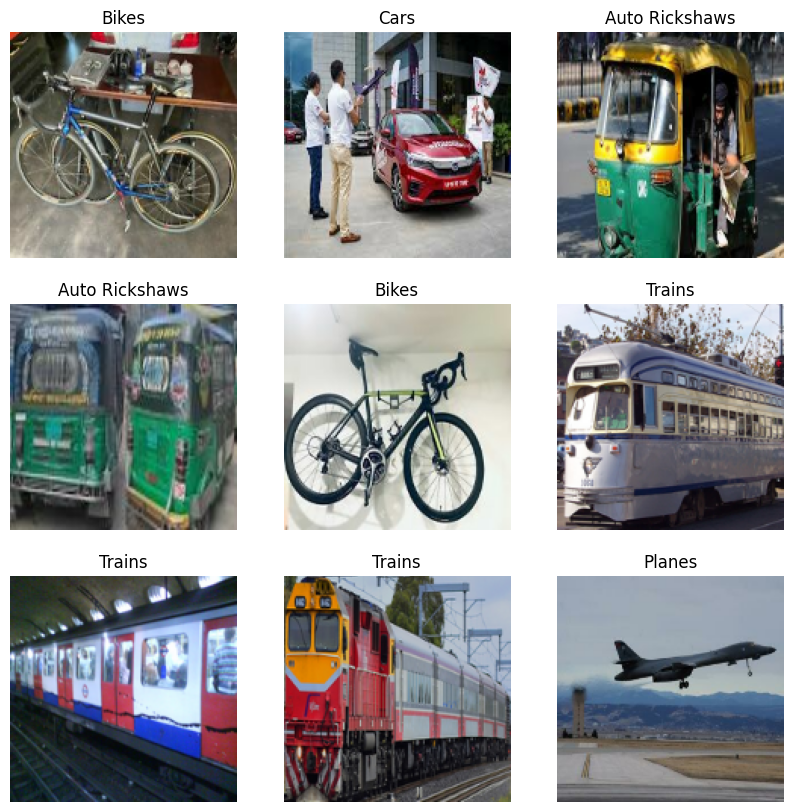

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [10]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 150, 150, 3)
(32,)


In [11]:
normalization_layer = layers.Rescaling(1./255)

train_ds=train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds=val_ds.map(lambda x, y: (normalization_layer(x), y))

In [12]:
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,255 (18.42 MB)

 Trainable params: 4,829,255 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.optimizers import SGD
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [14]:
epochs = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.4010 - loss: 1.5993 - val_accuracy: 0.6240 - val_loss: 1.0867
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.6048 - loss: 1.1274 - val_accuracy: 0.7261 - val_loss: 0.8165
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.6661 - loss: 0.9408 - val_accuracy: 0.7449 - val_loss: 0.7256
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.7072 - loss: 0.8420 - val_accuracy: 0.7484 - val_loss: 0.7090
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.7430 - loss: 0.7739 - val_accuracy: 0.7825 - val_loss: 0.6680
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.7600 - loss: 0.7086 - val_accuracy: 0.7842 - val_loss: 0.6391
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.7714 - loss: 0.6497 - val_accuracy: 0.7869 - val_loss: 0.6551
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.7974 - loss: 0.5915 - val_accu

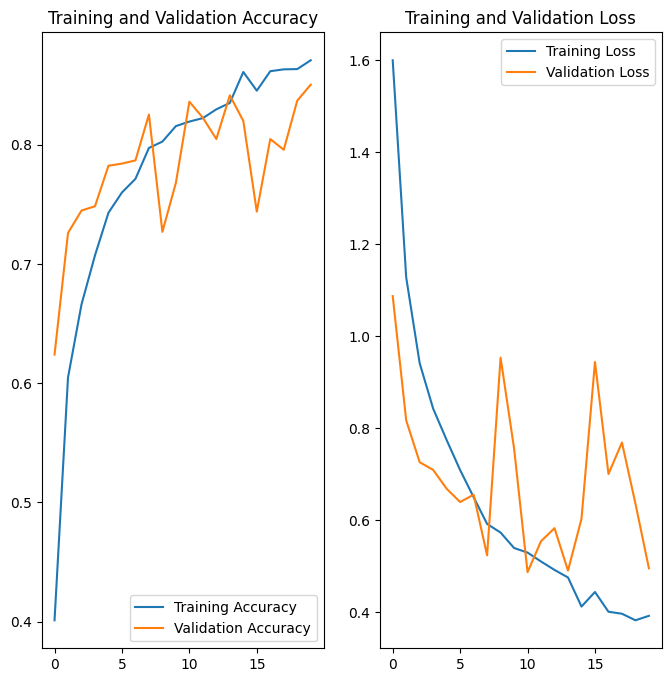

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [17]:
model.save("vehicle_classifier.h5")

Testing image: /content/vehicle_dataset/Trains/Train (106).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted: Trains
Actual: Trains


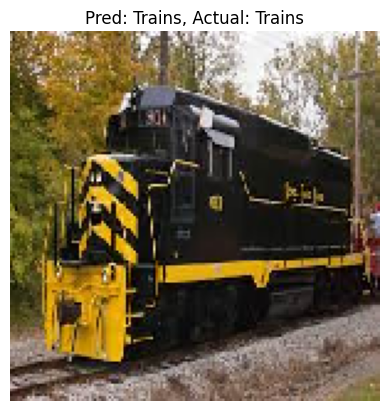

In [ ]:
from tensorflow.keras.preprocessing import image
import random
random_class = random.choice(class_names)
class_path = os.path.join(data_dir, random_class)

img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

print("Testing image:", img_path)
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]

print("Predicted:", predicted_class)
print("Actual:", random_class)

plt.imshow(img)
plt.title(f"Pred: {predicted_class}, Actual: {random_class}")
plt.axis("off")
plt.show()

In [19]:
from keras.preprocessing.image import load_img,img_to_array

In [ ]:
new_image = image.load_img('testing.jpg', target_size=(150, 150))
new_img_array = image.img_to_array(new_image) / 255.0
new_img_array = np.expand_dims(new_img_array, axis=0)

predictions = model.predict(new_img_array)
predicted_class = class_names[np.argmax(predictions)]
predicted_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


'Auto Rickshaws'